In [1]:
import pandas as pd
import networkx as nx
import numpy as np
from pathlib import Path

# Lấy ra các gen của bệnh gout

In [2]:
import pandas as pd

herb_target = pd.read_csv(r"D:\sciadv.adh0215_data_s1_to_s15\adh0215_Data_S1_to_S13\S4-1. HIT_herb_target_data_0412dropna.csv")

target_gout = pd.read_csv(r"D:\GeneCards-SearchResults.csv")
target_gout = target_gout[target_gout["Relevance score"] > 0.2]

In [3]:
herb_target_gout = pd.merge(herb_target, target_gout, left_on="Gene Symbol", right_on="Gene Symbol", how="inner").iloc[:, [0, 1, 2, 3, 4, 5, 7, 9, 10, 11, 12, 15, 16]] 
herb_target_gout.head(3)

,Target ID,Protein Name,Gene Symbol,Uniprot ID_x,Herb ID,Chinese Pin Yin,English_name,概念id,概念名,tcm_id,entrez_id,Uniprot ID_y,Gifts
0,T30D9G,Superoxide dismutase [Cu-Zn],SOD1,P00441,H0001,Ai Pian,Blumea camphor,U5,艾叶,U5,6647,P00441,66
1,T78ZF2,Protein kinase C alpha type,PRKCA,P17252,H0001,Ai Pian,Blumea camphor,U5,艾叶,U5,5578,P17252,64
2,T34FQX,Protein kinase C zeta type,PRKCZ,Q05513,H0001,Ai Pian,Blumea camphor,U5,艾叶,U5,5590,Q05513,61


In [4]:
#Lấy ra dược liệu có liên quan đến bệnh gút
#Lấy mã các target liên quan đến bệnh gút
herbs_gout = herb_target_gout["Herb ID"].unique()
entrez_ids = herb_target_gout["entrez_id"].unique()
Gene_symbols = herb_target_gout["Gene Symbol"].unique()
print(f"Số lượng dược liệu liên quan đến bệnh gút: {len(herbs_gout)}")
print(f"Số lượng mã gene liên quan đến bệnh gút: {len(entrez_ids)}")

Số lượng dược liệu liên quan đến bệnh gút: 881
Số lượng mã gene liên quan đến bệnh gút: 628


# Xử lý file S2 (sự tương tác giữa các gene (target))
* Lọc các tương tác giữa các gene của bệnh gout
* Tạo list các gene bệnh Gout

In [ ]:
my_genes = set(str(id).strip() for id in entrez_ids.tolist())

gene_interaction = pd.read_csv(r"D:\sciadv.adh0215_data_s1_to_s15\adh0215_Data_S1_to_S13\S2. interactome2019.txt", sep='\t')
gene_interaction.columns = ["proteinA", "proteinB", "databases"]
gene_interaction['proteinA'] = gene_interaction['proteinA'].astype(str).str.strip()
gene_interaction['proteinB'] = gene_interaction['proteinB'].astype(str).str.strip()
gene_gout_interaction = gene_interaction[
    gene_interaction['proteinA'].isin(my_genes) & 
    gene_interaction['proteinB'].isin(my_genes)
]


unique_genes = pd.unique(pd.concat([gene_gout_interaction['proteinA'], gene_gout_interaction['proteinB']]))


print(f"Số lượng gen: {len(unique_genes)}")
# 4. Kiểm tra kết quả
print(f"Số tương tác ban đầu: {len(gene_interaction)}")
print(f"Số tương tác sau khi lọc: {len(gene_gout_interaction)}")

# 5. Lưu kết quả ra file mới để dùng cho Cytoscape hoặc phân tích tiếp
gene_gout_interaction.to_csv('Filtered_interactome.txt', sep='\t', index=False)

Số lượng gen: 576
Số tương tác ban đầu: 327924
Số tương tác sau khi lọc: 3912


# Xử lý s1 (file chứa triệu chứng và gene liên quan)
* Lọc từ file dữ liệu có sẵn dựa theo các gene(target) phần trước

In [ ]:
import pandas as pd
#Đọc danh sách các triệu chứng và gen liên quan đến các triệu chứng đó
path = r"D:\sciadv.adh0215_data_s1_to_s15\adh0215_Data_S1_to_S13\S1. TCM_symptom_genes_s20_0427.txt"

# 1. Đọc file thủ công từng dòng để tránh lỗi ParserError của Pandas
data = []
with open(path, 'r', encoding='utf-8') as file:
    for line in file:
        # Xóa khoảng trắng/xuống dòng ở 2 đầu
        line = line.strip() 
        if not line:
            continue # Bỏ qua các dòng trống
            
        # Tách dòng thành một danh sách dựa trên dấu Tab (\t)
        parts = line.split('\t')
        
        # Phần tử đầu tiên (index 0) là Triệu chứng
        trieu_chung = parts[0]
        
        # Tất cả các phần tử từ index 1 trở đi là các Gene
        cac_gene = parts[1:]
        
        # Lưu vào danh sách data
        data.append({
            'symptoms': trieu_chung,
            'genes': cac_gene # Lưu dưới dạng List (danh sách)
        })


# 2. Chuyển đổi danh sách vừa thu được thành Pandas DataFrame
df = pd.DataFrame(data)
print(f"S1 shape: {df.shape}")
print(f"Unique symptoms: {df['symptoms'].nunique()}")
print(f"Unique genes: {df['genes'].apply(len).sum()}")
print("--- DỮ LIỆU ĐÃ ĐƯỢC GOM THÀNH 2 CỘT THÀNH CÔNG ---")


print(df.head())



#  Ép kiểu toàn bộ ID sang chuỗi (string) và đưa vào tập hợp (set)


def filter_my_genes(gene_list):
    # Đảm bảo g cũng được đưa về dạng chuỗi trước khi so sánh
    matched = [str(g).strip() for g in gene_list if str(g).strip() in unique_genes]
    
    return ", ".join(matched) if matched else None

# Áp dụng hàm lọc
df['gene_entrez'] = df['genes'].apply(filter_my_genes)

# Loại bỏ các triệu chứng không có gene nào khớp
final_df = df.dropna(subset=['gene_entrez'])

# Lấy bảng chứa các triệu chứng và gene liên quan đến bệnh gout
symptoms_gene_gout = final_df[['symptoms', 'gene_entrez']]

symptoms_gene_gout.loc[:, 'gene_entrez'] = symptoms_gene_gout['gene_entrez'].str.split(',')

symptoms_gene_gout_final = symptoms_gene_gout.explode('gene_entrez')

#Tạo bảng chứa các triệu chứng và gene liên quan đến bệnh gout sau khi tách thành từng dòng
symptoms_gene_gout_final['gene_entrez'] = symptoms_gene_gout_final['gene_entrez'].str.strip()

print("\n--- BẢNG KẾT QUẢ SAU KHI TÁCH THÀNH TỪNG DÒNG ---")
print(f"Số lượng dòng mới: {symptoms_gene_gout_final.shape[0]}")
print(symptoms_gene_gout_final.head(10))

S1 shape: (174, 2)
Unique symptoms: 174
Unique genes: 12601
--- DỮ LIỆU ĐÃ ĐƯỢC GOM THÀNH 2 CỘT THÀNH CÔNG ---
   symptoms                                              genes
0  C0022541  [6392, 56997, 55605, 644096, 10381, 291, 401, ...
1  C0023530  [7454, 1806, 1440, 79650, 2214, 6901, 7066, 14...
2  C0002103  [3269, 3567, 3497, 240, 3596, 6037, 55153, 267...
3  C0035455  [3269, 4852, 3567, 3497, 2908, 7356, 3596, 603...
4  C0009806  [1650, 5290, 2314, 2313, 259232, 779, 360, 544...

--- BẢNG KẾT QUẢ SAU KHI TÁCH THÀNH TỪNG DÒNG ---
Số lượng dòng mới: 1767
   symptoms gene_entrez
0  C0022541        3552
0  C0022541        3553
1  C0023530        1441
1  C0023530        1437
1  C0023530        2056
1  C0023530        4254
1  C0023530       54658
1  C0023530        2542
2  C0002103         240
2  C0002103        3596


* Tạo đồ thị PPI

In [7]:
G = nx.Graph()
G.add_edges_from(zip(gene_gout_interaction["proteinA"], gene_gout_interaction["proteinB"]))

print(f"Nodes: {G.number_of_nodes():,}")  
print(f"Edges: {G.number_of_edges():,}")  

# Kiểm tra connected components
# Mục đích: Protein nằm ngoài largest CC sẽ không tính được
# shortest path đến protein khác → phải biết để xử lý sau.
# Paper chỉ tính trên largest CC.
components = list(nx.connected_components(G))
largest_cc = max(components, key=len)

print(f"\nSố connected components: {len(components)}")
print(f"Largest CC: {len(largest_cc):,} nodes")
print(f"% nodes trong largest CC: {len(largest_cc)/G.number_of_nodes()*100:.1f}%")

Nodes: 576
Edges: 3,912

Số connected components: 32
Largest CC: 539 nodes
% nodes trong largest CC: 93.6%


In [8]:
# ---------------  Map symptom genes lên PPI -----------------------
# Mục đích: Chỉ giữ các gene có protein tương ứng trong largest
# CC của PPI. Protein nằm ngoài largest CC không tính được
# shortest path → loại bỏ để tránh sai lệch.

# Chỉ làm việc trên largest CC từ đây về sau
G_main = G.subgraph(largest_cc).copy()
ppi_nodes = set(G_main.nodes())

# Map từng symptom → tập protein trong PPI
symptom_proteins = {}
for cui, group in symptoms_gene_gout_final.groupby("symptoms"):
    genes = set(group["gene_entrez"].tolist())
    overlap = genes & ppi_nodes  # chỉ giữ gene có trong PPI
    if len(overlap) >= 10:       # filter như paper: >= 10 proteins
        symptom_proteins[cui] = overlap

print(f"Symptoms sau khi map lên PPI (>= 10 proteins): {len(symptom_proteins)}")

# Kiểm tra phân phối số protein mỗi symptom
protein_counts = [len(v) for v in symptom_proteins.values()]
print(f"Trung bình proteins/symptom: {np.mean(protein_counts):.1f}")
print(f"Min: {min(protein_counts)}, Max: {max(protein_counts)}")

# Tổng unique proteins cần dùng cho tính toán sau
all_symptom_proteins = set()
for proteins in symptom_proteins.values():
    all_symptom_proteins.update(proteins)
print(f"\nTổng unique symptom proteins: {len(all_symptom_proteins)}")

Symptoms sau khi map lên PPI (>= 10 proteins): 64
Trung bình proteins/symptom: 19.0
Min: 10, Max: 72

Tổng unique symptom proteins: 322


In [ ]:
# ──  Tính LCC z-score cho từng symptom ─────────────────────
# Mục đích: Kiểm tra protein của mỗi symptom có co cụm thành
# module trên PPI không, hay phân tán ngẫu nhiên.
# So sánh LCC thực tế với LCC của random node sets cùng kích
# thước và degree distribution → ra z-score.
# z > 1.6 = có module có ý nghĩa thống kê (paper dùng ngưỡng này)


import random
from collections import defaultdict

# Chuẩn bị degree bins
degrees = dict(G_main.degree())
degree_bins = defaultdict(list)
for node, deg in degrees.items():
    degree_bins[deg].append(node)

def get_lcc_size(nodes):
    """Kích thước largest connected component của node set trong G_main"""
    nodes_in_G = [n for n in nodes if n in G_main]
    if not nodes_in_G:
        return 0
    subgraph = G_main.subgraph(nodes_in_G)
    return max(len(c) for c in nx.connected_components(subgraph))

def compute_lcc_zscore(nodes, n_random=1000, seed=42):
    """
    Tính LCC z-score bằng degree-preserving randomization.
    seed=42: convention chuẩn trong research, đảm bảo reproducible.
    """
    random.seed(seed)
    observed_lcc = get_lcc_size(nodes)
    
    nodes_in_G = [n for n in nodes if n in G_main]
    node_degrees = [degrees[n] for n in nodes_in_G]
    
    random_lccs = []
    for _ in range(n_random):
        random_nodes = []
        for d in node_degrees:
            if d in degree_bins:
                random_nodes.append(random.choice(degree_bins[d]))
            else:
                closest = min(degree_bins.keys(), key=lambda x: abs(x - d))
                random_nodes.append(random.choice(degree_bins[closest]))
        random_lccs.append(get_lcc_size(random_nodes))
    
    mu = np.mean(random_lccs)
    sigma = np.std(random_lccs)
    z = (observed_lcc - mu) / sigma if sigma > 0 else 0.0
    
    return observed_lcc, round(mu, 2), round(sigma, 2), round(z, 3)

import time
print("Tính LCC z-score (n_random=1000)")

results_lcc_final = []
start = time.time()

for i, (cui, proteins) in enumerate(symptom_proteins.items()):
    lcc, mu, sigma, z = compute_lcc_zscore(proteins, n_random=1000)
    results_lcc_final.append({
        "symptom_CUI": cui,
        "n_proteins": len(proteins),
        "LCC_size": lcc,
        "LCC_mean_random": mu,
        "LCC_std_random": sigma,
        "LCC_zscore": z
    })
    if (i+1) % 30 == 0:
        elapsed = time.time() - start
        eta = elapsed / (i+1) * (64 - i - 1)
        print(f"  {i+1}/64 done | elapsed: {elapsed:.0f}s | ETA: {eta:.0f}s")

df_lcc_final = pd.DataFrame(results_lcc_final)
print(f"\nSymptoms z > 1.6: {(df_lcc_final['LCC_zscore'] > 1.6).sum()}/64")

Tính LCC z-score (n_random=1000)
  30/64 done | elapsed: 6s | ETA: 7s
  60/64 done | elapsed: 12s | ETA: 1s

Symptoms z > 1.6: 12/64


# GIAI ĐOẠN 2: SYMPTOM-SYMPTOM RELATIONSHIP

Bước 2.1: Tính Dab và Sab

- Mục đích: Đo khoảng cách mạng giữa 2 symptom module.

Dab = trung bình khoảng cách ngắn nhất từ mỗi protein trong A đến protein gần nhất trong B

 (Menche et al., Science 2015 — "Uncovering disease-disease relationships through the incomplete interactome")

Sab = Dab - (dAA + dBB)/2 → chuẩn hóa theo độ compact của từng module

(Cheng et al., Nature Communications 2019 — "Network-based prediction of drug combinations")
Nếu Sab < 0 → 2 symptom nằm trong cùng vùng PPI → có xu hướng đồng xuất hiện trong bệnh.

Bước 2.2: Validate với S3-2
- Mục đích: So sánh Sab tính được với ground truth của paper → xác nhận pipeline đúng trước khi đi tiếp.

In [ ]:
# ── Precompute shortest paths ──────────────────────────────
# Mục đích: Tính trước khoảng cách ngắn nhất giữa tất cả
# symptom proteins trên PPI, lưu vào dict để tái sử dụng.

import time

print(f"Tổng symptom proteins cần compute: {len(all_symptom_proteins)}")
print("Bắt đầu precompute")

path_cache = {}
start = time.time()

for i, node in enumerate(all_symptom_proteins):
    if node not in G_main:
        continue
    # Tính shortest path từ node này đến toàn bộ graph
    # Chỉ lưu distances đến symptom proteins để tiết kiệm RAM
    lengths = nx.single_source_shortest_path_length(G_main, node)
    path_cache[node] = {
        other: lengths[other]
        for other in all_symptom_proteins
        if other in lengths
    }
    if (i+1) % 500 == 0:
        elapsed = time.time() - start
        eta = elapsed / (i+1) * (len(all_symptom_proteins) - i - 1)
        print(f"  {i+1}/{len(all_symptom_proteins)} | elapsed: {elapsed:.0f}s | ETA: {eta:.0f}s")

print(f"\nPrecompute xong! Tổng thời gian: {time.time()-start:.0f}s")
print(f"Số nodes trong cache: {len(path_cache)}")

Tổng symptom proteins cần compute: 322
Bắt đầu precompute

Precompute xong! Tổng thời gian: 0s
Số nodes trong cache: 322


In [11]:
# ──  Tính Dab và Sab giữa các cặp symptom ──────────────────
# Mục đích: Đo khoảng cách mạng giữa 2 symptom module trên PPI.
#
# Dab = trung bình khoảng cách ngắn nhất từ mỗi protein trong A
#       đến protein gần nhất trong B
#       → đo mức độ "gần nhau" giữa 2 module
#
# dAA = trung bình khoảng cách ngắn nhất từ mỗi protein trong A
#       đến protein gần nhất TRONG CÙNG module A
#       → đo mức độ "compact" của module A
#
# Sab = Dab - (dAA + dBB) / 2
#       → chuẩn hóa Dab theo độ compact của từng module
#       → Sab < 0: 2 module nằm trong cùng vùng PPI (overlap)
#       → Sab > 0: 2 module tách biệt nhau
#       → Sab = 0: random expectation
#
# Công thức đúng theo Menche et al., Science 2015:
# dAB tính 2 chiều (A→B và B→A) để đảm bảo symmetric
# Nguồn: Menche 2015 + Cheng 2019 (Nat Comms)

from itertools import combinations
import time

def compute_sab_menche(nodes_a, nodes_b, cache):
    """
    Công thức Sab đúng theo Menche 2015.
    dAA: mỗi node a → closest node khác trong A
    dBB: mỗi node b → closest node khác trong B
    dAB: 2 chiều — A→B và B→A
    """
    nodes_a = [n for n in nodes_a if n in cache]
    nodes_b = [n for n in nodes_b if n in cache]
    if not nodes_a or not nodes_b:
        return np.nan, np.nan, np.nan, np.nan

    # dAA: mỗi node a → closest node khác trong A
    daa_dists = []
    for a in nodes_a:
        dists = [cache[a][b] for b in nodes_a if b != a and b in cache[a]]
        if dists:
            daa_dists.append(min(dists))
    daa = np.mean(daa_dists) if daa_dists else 0.0

    # dAA: mỗi node a → closest node khác trong A
    # => đo độ compact của module A
    dbb_dists = []
    for b in nodes_b:
        dists = [cache[b][a] for a in nodes_b if a != b and a in cache[b]]
        if dists:
            dbb_dists.append(min(dists))
    dbb = np.mean(dbb_dists) if dbb_dists else 0.0

    # dAB: 2 chiều — A→B và B→A
    # => đo khoảng cách giữa 2 module, tính cả 2 hướng để symmetric
    ab_dists = []
    for a in nodes_a:
        dists = [cache[a][b] for b in nodes_b if b in cache[a]]
        if dists:
            ab_dists.append(min(dists))
    for b in nodes_b:
        dists = [cache[b][a] for a in nodes_a if a in cache[b]]
        if dists:
            ab_dists.append(min(dists))

    dab = np.mean(ab_dists) if ab_dists else np.nan
    sab = dab - (daa + dbb) / 2

    return daa, dbb, dab, sab


symptom_list = list(symptom_proteins.keys())
print(f"Tổng cặp cần tính: {len(symptom_list)*(len(symptom_list)-1)//2:,}")
print("Tính Dab/Sab...")
start = time.time()

pair_results_menche = []
for cui_a, cui_b in combinations(symptom_list, 2):
    daa, dbb, dab, sab = compute_sab_menche(
        symptom_proteins[cui_a],
        symptom_proteins[cui_b],
        path_cache
    )
    pair_results_menche.append({
        "symptom_A": cui_a,
        "symptom_B": cui_b,
        "Dab": round(dab, 4),
        "Sab": round(sab, 4)
    })

df_pairs_menche = pd.DataFrame(pair_results_menche)
print(f"Xong! {time.time()-start:.1f}s")
print(f"Mean Dab: {df_pairs_menche['Dab'].mean():.3f}")
print(f"Mean Sab: {df_pairs_menche['Sab'].mean():.3f}")

# Thống kê tổng hợp
print(f"Tổng cặp symptom: {len(df_pairs_menche):,}")
print(f"Mean Sab: {df_pairs_menche['Sab'].mean():.3f} ")
print(f"Cặp Sab < 0 (overlap): {(df_pairs_menche['Sab'] < 0).sum():,}")
print(f"Cặp Sab > 0 (tách biệt): {(df_pairs_menche['Sab'] > 0).sum():,}")


Tổng cặp cần tính: 2,016
Tính Dab/Sab...
Xong! 0.8s
Mean Dab: 1.669
Mean Sab: 0.002
Tổng cặp symptom: 2,016
Mean Sab: 0.002 
Cặp Sab < 0 (overlap): 898
Cặp Sab > 0 (tách biệt): 1,102


# Giai đoạn 3 — Herb-symptom proximity 

- Mục đích: Đây là phần trung tâm của framework — đo khoảng cách từ protein đích của thảo dược đến symptom module trên PPI.
- proximity_d thấp = herb targets gần symptom module = herb tiềm năng điều trị.
- Validate bằng AUC: nếu indicated pairs (CHPH ghi nhận hiệu quả) có proximity thấp hơn non-indicated pairs → framework có giá trị dự đoán.

Bước 3.1: Load herb targets
Có 2 nguồn:

HIT 2.0 (S4-1): herb → protein trực tiếp, 798 herbs

TCMIO + STITCH (S4-2, S4-3): herb → chemical → protein, 461 herbs

Bước 3.2: Tính proximity z-score (8 pipelines)

- Mục đích: Đo khoảng cách từ target của herb đến symptom module trên PPI. Z-score âm = herb proximal với symptom = có khả năng điều trị.
- 8 pipelines = 2 nguồn target × 2 metrics (distance d và z-score) × 2 cách aggregate chemical targets (average và minimum).

Bước 3.3: Validate với CHPH indication data
- Mục đích: Kiểm tra AUC — các cặp herb–symptom đã được CHPH ghi nhận có proximity tốt hơn cặp không được ghi nhận không. Paper đạt AUC 0.65–0.72.

In [12]:
# Số lượng gene sau khi lọc 
print(f"Số lượng gene sau khi lọc: {len(unique_genes)}")

Số lượng gene sau khi lọc: 576


In [13]:
herb_target_gout['entrez_id'] = herb_target_gout['entrez_id'].astype(str)
unique_genes = set(map(str, unique_genes))

herb_target_gout_filtered = herb_target_gout[
    herb_target_gout['entrez_id'].isin(unique_genes)
]
len(herb_target_gout_filtered)

61590

In [14]:
# ── 9. Build herb targets dict từ HIT (S4-1) ─────────────────
# Mục đích: Tạo dict {herb_UID: set(entrez_ids)} để tính
# proximity sau này. Dùng cột '概念id' làm herb ID thống nhất
# vì đây là UID dùng trong S5-1 (ground truth).
# Chỉ giữ targets có protein trong PPI — targets ngoài PPI
# không tính được shortest path → bỏ qua.

herb_targets_HIT = {}
for uid, group in herb_target_gout_filtered.groupby("tcm_id"):
    targets = set(group["entrez_id"].dropna().astype(str).tolist())
    targets_in_PPI = targets & ppi_nodes
    if len(targets_in_PPI) > 0:
        herb_targets_HIT[uid] = targets_in_PPI

print(f"Số herbs có targets trong PPI: {len(herb_targets_HIT)}")
# Kỳ vọng: ~798 herbs

# Thống kê
target_counts = [len(v) for v in herb_targets_HIT.values()]
print(f"Trung bình targets/herb: {np.mean(target_counts):.1f}")
print(f"Min: {min(target_counts)}, Max: {max(target_counts)}")

# Tổng unique herb proteins
all_herb_proteins = set()
for targets in herb_targets_HIT.values():
    all_herb_proteins.update(targets)
print(f"\nTổng unique herb proteins: {len(all_herb_proteins)}")

# Xem vài herbs đầu
print("\nVí dụ:")
for uid, targets in list(herb_targets_HIT.items())[:3]:
    name = herb_target_gout_filtered[herb_target_gout_filtered["tcm_id"]==uid]["Chinese Pin Yin"].iloc[0]
    print(f"  {uid} ({name}): {len(targets)} targets")

Số herbs có targets trong PPI: 764
Trung bình targets/herb: 77.3
Min: 1, Max: 469

Tổng unique herb proteins: 539

Ví dụ:
  U10 (Ba Dou): 79 targets
  U100 (Shui Chang Pu): 32 targets
  U1002 (Chong Lou): 23 targets


In [15]:
# ── 10. Extend path_cache cho herb proteins ───────────────────
# Mục đích: path_cache hiện tại chỉ có distances giữa symptom
# proteins (~3409 nodes). Để tính proximity herb→symptom,
# cần thêm distances từ herb targets đến symptom proteins.
# Chỉ thêm herb proteins chưa có trong cache để tiết kiệm thời gian.

new_proteins = all_herb_proteins - set(path_cache.keys())
print(f"Herb proteins chưa có trong cache: {len(new_proteins)}")
print(f"Herb proteins đã có trong cache: {len(all_herb_proteins) - len(new_proteins)}")

if len(new_proteins) > 0:
    print(f"\nPrecompute thêm {len(new_proteins)} herb proteins...")
    start = time.time()
    
    for i, node in enumerate(new_proteins):
        if node not in G_main:
            continue
        lengths = nx.single_source_shortest_path_length(G_main, node)
        # Lưu distances đến symptom proteins
        # (herb proteins không cần distance đến nhau)
        path_cache[node] = {
            other: lengths[other]
            for other in all_symptom_proteins
            if other in lengths
        }
        if (i+1) % 200 == 0:
            elapsed = time.time() - start
            eta = elapsed / (i+1) * (len(new_proteins) - i - 1)
            print(f"  {i+1}/{len(new_proteins)} | elapsed: {elapsed:.0f}s | ETA: {eta:.0f}s")
    
    print(f"Xong! {time.time()-start:.0f}s")
else:
    print("Tất cả herb proteins đã có trong cache!")

print(f"\nTổng nodes trong cache: {len(path_cache)}")

Herb proteins chưa có trong cache: 217
Herb proteins đã có trong cache: 322

Precompute thêm 217 herb proteins...
  200/217 | elapsed: 0s | ETA: 0s
Xong! 0s

Tổng nodes trong cache: 539


In [16]:
# ── Bước 3.2: Build distance matrix để tính z-score nhanh ─────
# Mục đích: Thay vì tính shortest path từng cặp riêng lẻ,
# build sẵn ma trận NxN chứa tất cả distances giữa
# herb proteins và symptom proteins.
# → Tính proximity_d và random_d bằng numpy vectorized
# → Nhanh hơn ~1000x so với tính từng cặp

# Lấy tất cả proteins cần thiết
all_needed = list(all_herb_proteins | all_symptom_proteins)
all_needed = [n for n in all_needed if n in G_main]
protein_to_idx = {p: i for i, p in enumerate(all_needed)}
n_proteins = len(all_needed)

print(f"Tổng proteins trong matrix: {n_proteins}")

# Build matrix từ path_cache
print("Building distance matrix...")
dist_matrix = np.full((n_proteins, n_proteins), np.inf, dtype=np.float32)
np.fill_diagonal(dist_matrix, 0)

for p in all_needed:
    if p not in path_cache:
        continue
    i = protein_to_idx[p]
    for q, d in path_cache[p].items():
        if q in protein_to_idx:
            j = protein_to_idx[q]
            dist_matrix[i, j] = d

print(f"Matrix shape: {dist_matrix.shape}")
print(f"Memory: {dist_matrix.nbytes/1024**2:.1f} MB")
inf_pct = np.isinf(dist_matrix).sum() / dist_matrix.size * 100
print(f"Inf entries: {inf_pct:.1f}% (proteins không connected)")

# ── Test tốc độ proximity_d với numpy ────────────────────────
def compute_proximity_d_numpy(herb_targets, symptom_prots,
                               dist_matrix, protein_to_idx):
    # Lấy index của herb targets và symptom proteins
    t_idx = [protein_to_idx[t] for t in herb_targets
             if t in protein_to_idx]
    s_idx = [protein_to_idx[s] for s in symptom_prots
             if s in protein_to_idx]
    if not t_idx or not s_idx:
        return np.nan

    # Submatrix: herb_targets × symptom_proteins
    sub = dist_matrix[np.ix_(t_idx, s_idx)]

    # Min distance từ mỗi target đến closest symptom
    min_dists = np.min(sub, axis=1)

    # Bỏ inf (không connected)
    valid = min_dists[~np.isinf(min_dists)]
    return float(np.mean(valid)) if len(valid) > 0 else np.nan

print("\nTest tốc độ proximity_d numpy...")
start = time.time()
for uid, targets in herb_targets_HIT.items():
    for sym, prots in symptom_proteins.items():
        compute_proximity_d_numpy(targets, prots,
                                   dist_matrix, protein_to_idx)
elapsed = time.time() - start
print(f"{elapsed:.1f}s")
print(f"Tốc độ: {138852/elapsed:.0f} cặp/s")

Tổng proteins trong matrix: 539
Building distance matrix...
Matrix shape: (539, 539)
Memory: 1.1 MB
Inf entries: 40.2% (proteins không connected)

Test tốc độ proximity_d numpy...
3.4s
Tốc độ: 40389 cặp/s


In [17]:
# ── Bước 3.2: Tính proximity_d (Pipeline P1) ─────────────────
# Mục đích: Đo khoảng cách mạng từ herb targets đến symptom module.
# proximity_d = mean của min distance từ mỗi herb target đến
#               closest symptom protein → thấp = herb proximal với symptom
# Dùng numpy vectorized từ distance matrix → tốc độ ~4000 cặp/giây.
 
def compute_proximity_d_numpy(herb_targets, symptom_prots,
                               dist_matrix, protein_to_idx):
    """
    proximity_d = mean(min distance từ mỗi herb target → closest symptom protein)
    Dùng numpy indexing từ distance matrix → cực nhanh.
    """
    # Lấy index trong distance matrix
    t_idx = [protein_to_idx[t] for t in herb_targets if t in protein_to_idx]
    s_idx = [protein_to_idx[s] for s in symptom_prots if s in protein_to_idx]
    if not t_idx or not s_idx:
        return np.nan
 
    # Submatrix: herb_targets × symptom_proteins
    sub = dist_matrix[np.ix_(t_idx, s_idx)]
 
    # Min distance từ mỗi target đến closest symptom
    min_dists = np.min(sub, axis=1)
 
    # Bỏ inf (protein không connected trong PPI)
    valid = min_dists[~np.isinf(min_dists)]
    return float(np.mean(valid)) if len(valid) > 0 else np.nan
 
 
print(f"\nTính proximity_d cho {len(herb_targets_HIT)} herbs × {len(symptom_proteins)} symptoms...")
print(f"Tổng: {len(herb_targets_HIT)*len(symptom_proteins):,} cặp (~11 phút)")
start = time.time()
 
p1_results = []
for i, (uid, targets) in enumerate(herb_targets_HIT.items()):
    for sym, prots in symptom_proteins.items():
        d = compute_proximity_d_numpy(targets, prots, dist_matrix, protein_to_idx)
        p1_results.append({
            "herb_id": uid,
            "UMLS_id": sym,
            "proximity_d": round(d, 6) if not np.isnan(d) else np.nan
        })
    if (i + 1) % 100 == 0:
        elapsed = time.time() - start
        eta = elapsed / (i + 1) * (len(herb_targets_HIT) - i - 1)
        print(f"  {i+1}/{len(herb_targets_HIT)} | elapsed: {elapsed:.0f}s | ETA: {eta:.0f}s")
 
df_p1 = pd.DataFrame(p1_results)
print(f"Xong! {time.time()-start:.0f}s")


Tính proximity_d cho 764 herbs × 64 symptoms...
Tổng: 48,896 cặp (~11 phút)
  100/764 | elapsed: 0s | ETA: 3s
  200/764 | elapsed: 1s | ETA: 3s
  300/764 | elapsed: 2s | ETA: 2s
  400/764 | elapsed: 2s | ETA: 2s
  500/764 | elapsed: 2s | ETA: 1s
  600/764 | elapsed: 3s | ETA: 1s
  700/764 | elapsed: 3s | ETA: 0s
Xong! 4s


In [18]:
# # ── Bước 3.3: Tính proximity z-score (Pipeline P2) ───────────────────────────
# # Mục đích: Chuẩn hóa proximity_d so với phân phối ngẫu nhiên
# # cùng kích thước và degree distribution → loại bỏ bias từ
# # kích thước herb target set và symptom module size.
# #
# # z = (d_observed - mean_random) / std_random
# # z càng âm → herb càng gần symptom hơn mức ngẫu nhiên
# # Ngưỡng thông thường: z < -1.5 là proximal có ý nghĩa
# #
# # Lý do dùng degree-preserving (giống LCC z-score):
# # Tránh inflate null distribution do hub proteins.

# def compute_proximity_zscore(herb_targets, symptom_prots,
#                               dist_matrix, protein_to_idx,
#                               degree_bins, n_random=1000, seed=42):
#     """
#     Tính z-score cho proximity_d bằng degree-preserving randomization.
#     Random hóa herb targets (giữ nguyên symptom proteins cố định).
    
#     Returns: d_obs, mean_random, std_random, z_score
#     """
#     random.seed(seed)

#     t_idx = [protein_to_idx[t] for t in herb_targets if t in protein_to_idx]
#     s_idx = [protein_to_idx[s] for s in symptom_prots if s in protein_to_idx]
#     if not t_idx or not s_idx:
#         return np.nan, np.nan, np.nan, np.nan

#     # ── d thực tế ──
#     sub_obs  = dist_matrix[np.ix_(t_idx, s_idx)]
#     min_obs  = np.min(sub_obs, axis=1)
#     valid    = min_obs[~np.isinf(min_obs)]
#     d_obs    = float(np.mean(valid)) if len(valid) > 0 else np.nan
#     if np.isnan(d_obs):
#         return np.nan, np.nan, np.nan, np.nan

#     # ── Degree của các herb targets thực tế ──
#     herb_in_G  = [t for t in herb_targets if t in protein_to_idx]
#     herb_degs  = [degrees.get(t, 0) for t in herb_in_G]

#     # ── Phân phối null: random hóa herb targets ──
#     random_ds = []
#     for _ in range(n_random):
#         rand_targets = []
#         for d in herb_degs:
#             if d in degree_bins:
#                 rand_targets.append(random.choice(degree_bins[d]))
#             else:
#                 closest = min(degree_bins.keys(), key=lambda x: abs(x - d))
#                 rand_targets.append(random.choice(degree_bins[closest]))

#         r_idx = [protein_to_idx[r] for r in rand_targets if r in protein_to_idx]
#         if not r_idx:
#             continue
#         sub_r   = dist_matrix[np.ix_(r_idx, s_idx)]
#         min_r   = np.min(sub_r, axis=1)
#         valid_r = min_r[~np.isinf(min_r)]
#         if len(valid_r) > 0:
#             random_ds.append(float(np.mean(valid_r)))

#     if len(random_ds) < 10:          # quá ít mẫu → không tin cậy
#         return d_obs, np.nan, np.nan, np.nan

#     mu    = float(np.mean(random_ds))
#     sigma = float(np.std(random_ds))
#     z     = (d_obs - mu) / sigma if sigma > 0 else 0.0

#     return round(d_obs, 6), round(mu, 6), round(sigma, 6), round(z, 4)


# # ── Chạy tính z-score ─────────────────────────────────────────────────────────
# # Chú ý: mỗi cặp chạy 1000 vòng random → chậm hơn P1 nhiều
# # Nếu có >10k cặp, giảm n_random=200 cho prototype, dùng 1000 cho final run
# N_RANDOM = 1000

# print(f"\nTính proximity z-score ({N_RANDOM} randomizations/cặp)...")
# print(f"Tổng: {len(df_p1):,} cặp — ước tính ~{len(df_p1)*N_RANDOM//50000} phút")
# start = time.time()

# z_results = []
# for i, row in df_p1.iterrows():
#     uid = row["herb_id"]
#     sym = row["UMLS_id"]

#     targets = herb_targets_HIT.get(uid, set())
#     prots   = symptom_proteins.get(sym, set())

#     d_obs, mu, sigma, z = compute_proximity_zscore(
#         targets, prots,
#         dist_matrix, protein_to_idx,
#         degree_bins,
#         n_random=N_RANDOM,
#         seed=42
#     )
#     z_results.append({
#         "herb_id":          uid,
#         "UMLS_id":          sym,
#         "proximity_d":      row["proximity_d"],
#         "d_mean_random":    mu,
#         "d_std_random":     sigma,
#         "proximity_zscore": z
#     })

#     if (i + 1) % 500 == 0:
#         elapsed = time.time() - start
#         eta     = elapsed / (i + 1) * (len(df_p1) - i - 1)
#         print(f"  {i+1:,}/{len(df_p1):,} | elapsed: {elapsed:.0f}s | ETA: {eta:.0f}s")

# df_p2 = pd.DataFrame(z_results)
# print(f"\nXong! {time.time()-start:.0f}s")

# # ── Merge vào df_auc ──────────────────────────────────────────────────────────
# df_auc = df_auc.merge(
#     df_p2[["herb_id", "UMLS_id", "proximity_zscore",
#            "d_mean_random", "d_std_random"]],
#     on=["herb_id", "UMLS_id"],
#     how="left"
# )

# # ── Kiểm tra nhanh ────────────────────────────────────────────────────────────
# print("\n── Thống kê proximity z-score ──")
# print(df_auc["proximity_zscore"].describe().round(4))
# print(f"\nCặp z < -1.5 (proximal có ý nghĩa): "
#       f"{(df_auc['proximity_zscore'] < -1.5).sum():,} "
#       f"({(df_auc['proximity_zscore'] < -1.5).mean()*100:.1f}%)")

# # So sánh AUC: d thô vs z-score
# from sklearn.metrics import roc_auc_score
# mask = df_auc["indication"].notna() & df_auc["proximity_zscore"].notna()
# auc_d = roc_auc_score(df_auc.loc[mask, "indication"],
#                       -df_auc.loc[mask, "proximity_d"])
# auc_z = roc_auc_score(df_auc.loc[mask, "indication"],
#                       -df_auc.loc[mask, "proximity_zscore"])
# print(f"\nAUC — proximity d:       {auc_d:.4f}")
# print(f"AUC — proximity z-score: {auc_z:.4f}")
# print(f"Cải thiện:               {auc_z - auc_d:+.4f}")

# Đã tính z-score cho herb - gene

In [20]:
df_p2 = pd.read_csv(r"D:\nckh_313\proximity_P2_final.csv")

In [21]:
# Load S5-1 — chỉ lấy cột indication (CHPH ground truth)
# indication=1: cặp herb-symptom được CHPH ghi nhận hiệu quả
# indication=0: chưa được ghi nhận
# Đây là dữ liệu thực tế từ Chinese Pharmacopoeia,
# không phải kết quả tính toán của paper

s5_1 = pd.read_csv(
    "D:\\sciadv.adh0215_data_s1_to_s15\\adh0215_Data_S1_to_S13\S5-1. P1&P2 TCM_HIT_symptom_proximity_0416-2022_annotated.csv",
    encoding="utf-8-sig",
    usecols=["herb_id", "UMLS_id", "indication"]  # chỉ load 3 cột cần thiết
)
print(f"S5-1 shape: {s5_1.shape}")
print(f"Indicated pairs: {s5_1['indication'].sum():,}")
print(f"Non-indicated:   {(s5_1['indication']==0).sum():,}")

S5-1 shape: (138896, 3)
Indicated pairs: 1,480
Non-indicated:   137,416


# Tính AUC dựa trên d 

In [22]:
# ── Bước 3.3: Tính AUC validate framework (P1) ───────────────
# Mục đích: Kiểm tra proximity_d có dự đoán được herb-symptom
# effectiveness không. Dùng indication data từ CHPH làm ground truth.
# AUC > 0.5 = proximity có giá trị dự đoán
# Kỳ vọng P1: AUC ~0.65 (theo paper)

from sklearn.metrics import roc_auc_score
from scipy.stats import mannwhitneyu

# Merge proximity_d với indication
df_auc = df_p1.merge(
    s5_1[["herb_id","UMLS_id","indication"]],
    on=["herb_id","UMLS_id"], how="inner"
)

print(f"Tổng cặp: {len(df_auc):,}")
print(f"Indicated pairs: {df_auc['indication'].sum():,}")
print(f"Non-indicated:   {(df_auc['indication']==0).sum():,}")

# Tính AUC
# Dùng -proximity_d vì lower = better = more likely indicated
auc_value = roc_auc_score(df_auc["indication"], -df_auc["proximity_d"])
print(f"\nAUC (P1): {auc_value:.4f}")
print(f"Kỳ vọng paper: ~0.65")

# Mann-Whitney U test
indicated = df_auc[df_auc["indication"]==1]["proximity_d"]
non_indicated = df_auc[df_auc["indication"]==0]["proximity_d"]
stat, pval = mannwhitneyu(indicated, non_indicated, alternative="less")
print(f"Mann-Whitney p-value: {pval:.2e}")
print(f"Mean proximity indicated:     {indicated.mean():.4f}")
print(f"Mean proximity non-indicated: {non_indicated.mean():.4f}")

Tổng cặp: 48,928
Indicated pairs: 1,109
Non-indicated:   47,819

AUC (P1): 0.6622
Kỳ vọng paper: ~0.65
Mann-Whitney p-value: 1.08e-76
Mean proximity indicated:     1.4651
Mean proximity non-indicated: 1.5855


In [23]:
# ── Save kết quả Giai đoạn 3 ─────────────────────────────────
# Mục đích: Lưu proximity_d + indication để dùng trong Giai đoạn 4
# và báo cáo kết quả. Thêm tên herb cho dễ đọc.
import numpy as np
# Thêm tên herb vào df_p1
herb_names = herb_target_gout_filtered[["tcm_id", "Chinese Pin Yin", "English_name"]] \
    .drop_duplicates(subset="tcm_id") \
    .rename(columns={"tcm_id": "herb_id"})

df_p1_final = df_p1.merge(
    s5_1[["herb_id", "UMLS_id", "indication"]],
    on=["herb_id", "UMLS_id"], how="inner"
).merge(herb_names, on="herb_id", how="left")

df_p1_final = df_p1_final[[
    "herb_id", "Chinese Pin Yin", "English_name",
    "UMLS_id", "proximity_d", "indication"
]]

df_p1_final.to_csv( "D://nckh_313//proximity_P1_final.csv", index=False)
print(f"Đã save: proximity_P1_final.csv")
print(f"Shape: {df_p1_final.shape}")

# Save AUC summary
pd.DataFrame([{
    "Pipeline": "P1 (HIT, proximity_d)",
    "AUC": round(auc_value, 4),
    "p_value": f"{pval:.2e}",
    "n_indicated": int(indicated.shape[0]),
    "n_non_indicated": int(non_indicated.shape[0]),
    "mean_proximity_indicated": round(indicated.mean(), 4),
    "mean_proximity_non_indicated": round(non_indicated.mean(), 4)
}]).to_csv("D://nckh_313//auc_summary.csv", index=False)
print("Đã save: auc_summary.csv")

print(f"  {indicated.mean():.4f} vs {non_indicated.mean():.4f}")

Đã save: proximity_P1_final.csv
Shape: (48928, 6)
Đã save: auc_summary.csv
  1.4651 vs 1.5855


# Tính với z-score

In [ ]:
from sklearn.metrics import roc_auc_score
from scipy.stats import mannwhitneyu

# Merge proximity_d với indication
df_auc_2 = df_p2.merge(
    s5_1[["herb_id","UMLS_id","indication"]],
    on=["herb_id","UMLS_id"], how="inner"
)

print(f"Tổng cặp: {len(df_auc_2):,}")
print(f"Indicated pairs: {df_auc_2['indication'].sum():,}")
print(f"Non-indicated:   {(df_auc_2['indication']==0).sum():,}")

df_auc_2["proximity_zscore"].fillna(2, inplace=True) # NaN = không connected → đặt z-score cao (không proximal)

# Tính AUC
# Dùng -proximity_d vì lower = better = more likely indicated
auc_value_2 = roc_auc_score(df_auc_2["indication"], -df_auc_2["proximity_zscore"])
print(f"\nAUC (P2): {auc_value_2:.4f}")
print(f"Kỳ vọng paper: ~0.65")

# Mann-Whitney U test
indicated = df_auc_2[df_auc_2["indication"]==1]["proximity_zscore"]
non_indicated = df_auc_2[df_auc_2["indication"]==0]["proximity_zscore"]
stat, pval = mannwhitneyu(indicated, non_indicated, alternative="less")
print(f"Mann-Whitney p-value: {pval:.2e}")
print(f"Mean proximity indicated:     {indicated.mean():.4f}")
print(f"Mean proximity non-indicated: {non_indicated.mean():.4f}")

Tổng cặp: 48,928
Indicated pairs: 1,109
Non-indicated:   47,819

AUC (P2): 0.6448
Kỳ vọng paper: ~0.65
Mann-Whitney p-value: 5.40e-62
Mean proximity indicated:     -0.3696
Mean proximity non-indicated: 0.4548


In [34]:
import numpy as np
# Thêm tên herb 
herb_names = herb_target_gout_filtered[["tcm_id", "Chinese Pin Yin", "English_name"]] \
    .drop_duplicates(subset="tcm_id") \
    .rename(columns={"tcm_id": "herb_id"})

df_p2_final = df_p2.merge(
    s5_1[["herb_id", "UMLS_id", "indication"]],
    on=["herb_id", "UMLS_id"], how="inner"
).merge(herb_names, on="herb_id", how="left")

df_p2_final = df_p2_final[[
    "herb_id", "Chinese Pin Yin", "English_name",
    "UMLS_id", "proximity_d", "indication"
]]

df_p2_final.to_csv( "D://nckh_313//proximity_P2_final.csv", index=False)
print(f"Đã save: proximity_P2_final.csv")
print(f"Shape: {df_p2_final.shape}")

# Save AUC summary
pd.DataFrame([{
    "Pipeline": "P2 (HIT, proximity_d)",
    "AUC": round(auc_value_2, 4),
    "p_value": f"{pval:.2e}",
    "n_indicated": int(indicated.shape[0]),
    "n_non_indicated": int(non_indicated.shape[0]),
    "mean_proximity_indicated": round(indicated.mean(), 4),
    "mean_proximity_non_indicated": round(non_indicated.mean(), 4)
}]).to_csv("D://nckh_313//auc_summary_zscore.csv", index=False)
print("Đã save: auc_summary.csv")

print(f"  {indicated.mean():.4f} vs {non_indicated.mean():.4f}")

Đã save: proximity_P2_final.csv
Shape: (48928, 6)
Đã save: auc_summary.csv
  -0.4147 vs 0.2641


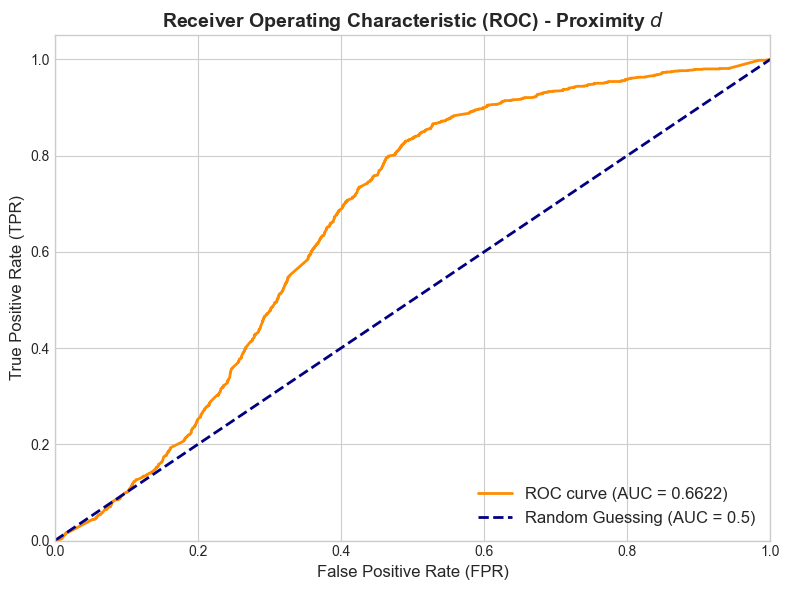

C:\Users\Admin\AppData\Local\Temp\ipykernel_8956\2564416608.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="indication", y="proximity_d", data=df_auc, ax=axes[0], palette="Set2")
C:\Users\Admin\AppData\Local\Temp\ipykernel_8956\2564416608.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="indication", y="proximity_d", data=df_auc, ax=axes[1], palette="Set2", inner="quartile")


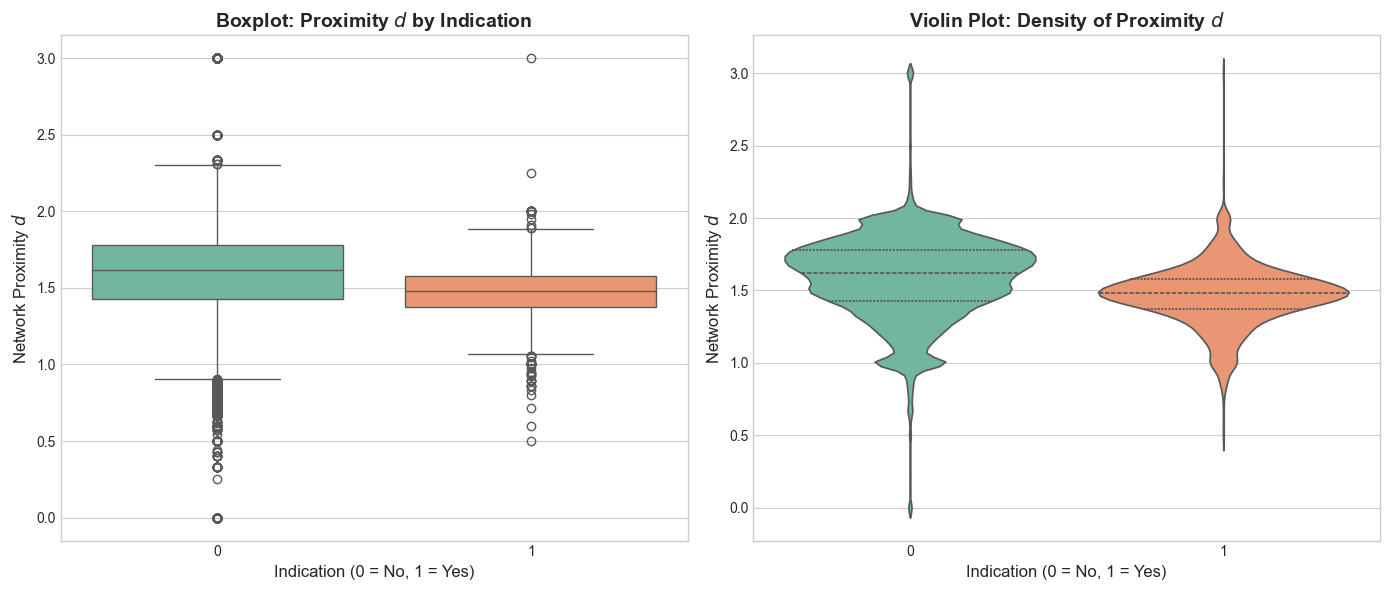

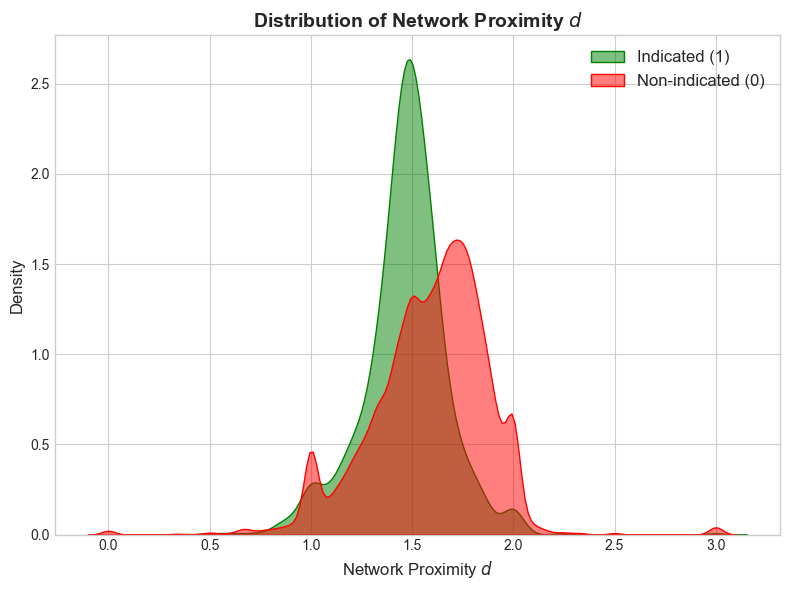

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.metrics import roc_curve, auc

# Thiết lập style cho biểu đồ đẹp hơn
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# ==========================================
# 1. BIỂU ĐỒ ROC CURVE (ĐÁNH GIÁ MÔ HÌNH)
# ==========================================
plt.figure(figsize=(8, 6))
# Lưu ý: dùng -proximity_d vì khoảng cách càng nhỏ càng tốt
fpr, tpr, thresholds = roc_curve(df_auc["indication"], -df_auc["proximity_d"])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) - Proximity $d$', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# 2. BOXPLOT & VIOLIN PLOT (MANN-WHITNEY VISUALIZATION)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(x="indication", y="proximity_d", data=df_auc, ax=axes[0], palette="Set2")
axes[0].set_title("Boxplot: Proximity $d$ by Indication", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Indication (0 = No, 1 = Yes)", fontsize=12)
axes[0].set_ylabel("Network Proximity $d$", fontsize=12)

# Violin plot (Xem chi tiết mật độ phân bố)
sns.violinplot(x="indication", y="proximity_d", data=df_auc, ax=axes[1], palette="Set2", inner="quartile")
axes[1].set_title("Violin Plot: Density of Proximity $d$", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Indication (0 = No, 1 = Yes)", fontsize=12)
axes[1].set_ylabel("Network Proximity $d$", fontsize=12)

plt.tight_layout()
plt.show()

# ==========================================
# 3. KERNEL DENSITY ESTIMATION (KDE PLOT)
# ==========================================
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df_auc[df_auc['indication'] == 1], x="proximity_d", fill=True, label="Indicated (1)", color="green", alpha=0.5)
sns.kdeplot(data=df_auc[df_auc['indication'] == 0], x="proximity_d", fill=True, label="Non-indicated (0)", color="red", alpha=0.5)

plt.title('Distribution of Network Proximity $d$', fontsize=14, fontweight='bold')
plt.xlabel('Network Proximity $d$', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()



# Tìm ngưỡng

In [ ]:
import numpy as np

# 1. Tính Youden's J statistic cho tất cả các ngưỡng
youden_j = tpr - fpr

# 2. Tìm vị trí (index) có giá trị J lớn nhất
best_index = np.argmax(youden_j)

# 3. Lấy ra ngưỡng tốt nhất tại vị trí đó
best_threshold = thresholds[best_index]

# LƯU Ý QUAN TRỌNG: 
# Vì lúc đưa vào hàm roc_curve mình đã để dấu trừ (-proximity_d)
# Nên bây giờ mình phải bỏ dấu trừ đi để lấy lại khoảng cách d thực tế
optimal_d = -best_threshold

print("=== TÌM NGƯỠNG TỐI ƯU (YOUDEN'S INDEX) ===")
print(f"Ngưỡng khoảng cách d tốt nhất: {optimal_d:.4f}")
print(f"Tại ngưỡng này:")
print(f" - Tỷ lệ đoán trúng đích (True Positive Rate): {tpr[best_index]*100:.1f}%")
print(f" - Tỷ lệ báo động giả (False Positive Rate) : {fpr[best_index]*100:.1f}%")

=== TÌM NGƯỠNG TỐI ƯU (YOUDEN'S INDEX) ===
Ngưỡng khoảng cách d tốt nhất: 1.6143
Tại ngưỡng này:
 - Tỷ lệ đoán trúng đích (True Positive Rate): 83.0%
 - Tỷ lệ báo động giả (False Positive Rate) : 49.0%


✅ Dùng dữ liệu sẵn có trong notebook kernel.

Tổng triệu chứng: 64
Lưu hình vào: D:\nckh_313

Figure 4: LCC z-score Bubble Chart …


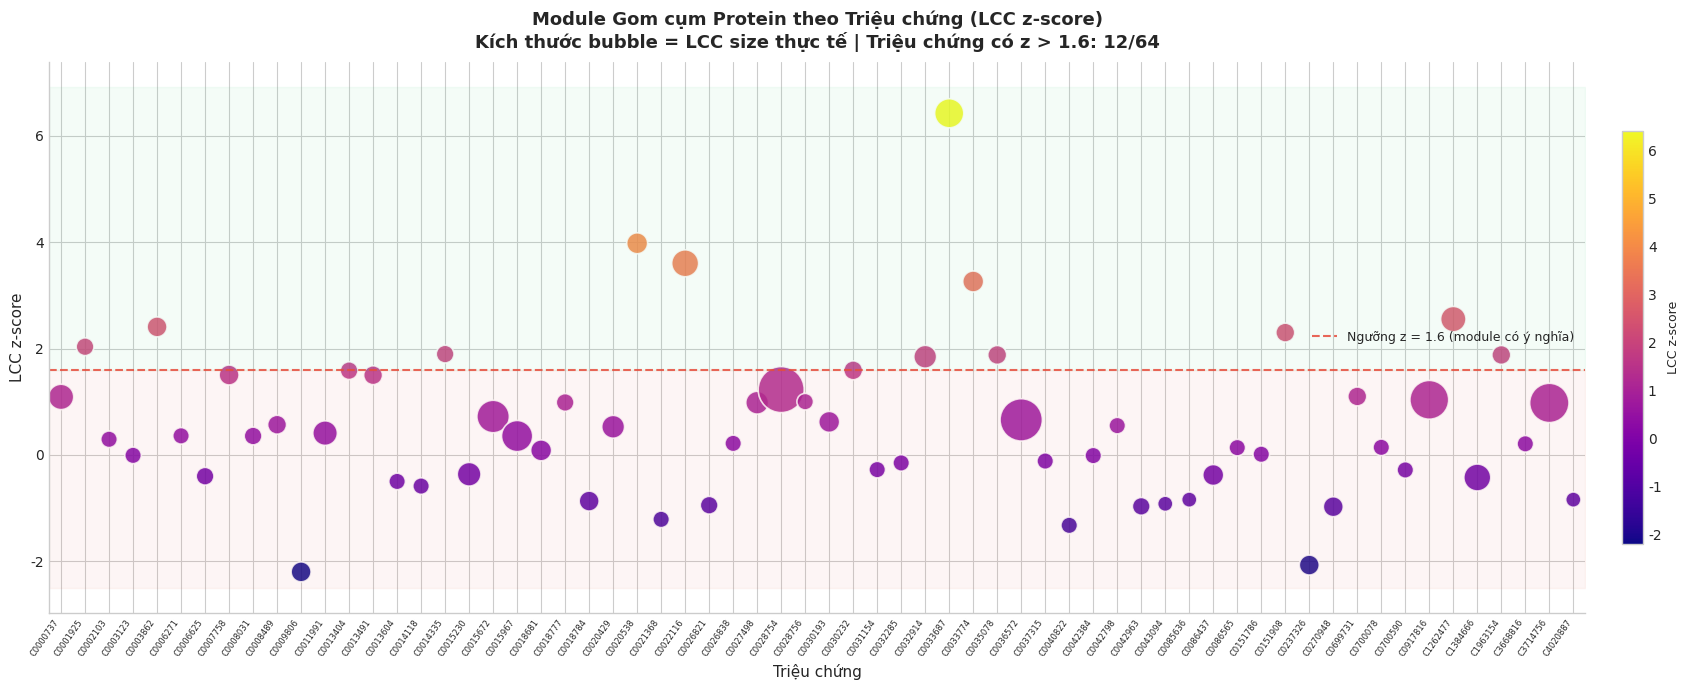

  → Đã lưu: D:\nckh_313\fig4_lcc_bubble_chart.png

═══════════════════════════════════════════════════════
✅ HOÀN TẤT! Các file đã lưu vào: D:\nckh_313
  • fig1_protein_symptom_network.png
  • fig2_jaccard_heatmap.png
  • fig3_tsne_protein_clustering.png
  • fig4_lcc_bubble_chart.png
  • fig5_symptom_network_sab.png (nếu có Sab)
═══════════════════════════════════════════════════════


In [43]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import networkx as nx
from collections import defaultdict
from itertools import combinations
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

# ══════════════════════════════════════════════════════════════════════════════
# BƯỚC 0 — Load dữ liệu (bỏ qua nếu đang chạy trong notebook đã có sẵn biến)
# ══════════════════════════════════════════════════════════════════════════════
import sys

def load_data_from_scratch():
    """
    Tái tạo symptom_proteins, df_lcc_final, G_main từ file gốc.
    Chỉ cần thiết khi chạy script độc lập (không qua notebook).
    """
    print("=" * 60)
    print("Load dữ liệu từ file gốc ...")
    print("=" * 60)

    # ── 1. GeneCards (gene bệnh gout) ──────────────────────────────────────
    target_gout = pd.read_csv(r"D:\GeneCards-SearchResults.csv")
    target_gout = target_gout[target_gout["Relevance score"] > 0.2]

    # ── 2. HIT herb-target ─────────────────────────────────────────────────
    herb_target = pd.read_csv(
        r"D:\sciadv.adh0215_data_s1_to_s15\adh0215_Data_S1_to_S13"
        r"\S4-1. HIT_herb_target_data_0412dropna.csv"
    )
    herb_target_gout = pd.merge(
        herb_target, target_gout,
        left_on="Gene Symbol", right_on="Gene Symbol", how="inner"
    ).iloc[:, [0, 1, 2, 3, 4, 5, 7, 9, 10, 11, 12, 15, 16]]

    entrez_ids   = herb_target_gout["entrez_id"].unique()
    unique_genes = set(str(i).strip() for i in entrez_ids.tolist())

    # ── 3. PPI interactome ─────────────────────────────────────────────────
    gene_interaction = pd.read_csv(
        r"D:\sciadv.adh0215_data_s1_to_s15\adh0215_Data_S1_to_S13"
        r"\S2. interactome2019.txt",
        sep="\t", header=None, names=["proteinA", "proteinB", "databases"]
    )
    gene_interaction["proteinA"] = gene_interaction["proteinA"].astype(str).str.strip()
    gene_interaction["proteinB"] = gene_interaction["proteinB"].astype(str).str.strip()

    gene_gout_interaction = gene_interaction[
        gene_interaction["proteinA"].isin(unique_genes) &
        gene_interaction["proteinB"].isin(unique_genes)
    ]

    G = nx.Graph()
    G.add_edges_from(zip(gene_gout_interaction["proteinA"],
                         gene_gout_interaction["proteinB"]))
    largest_cc = max(nx.connected_components(G), key=len)
    G_main     = G.subgraph(largest_cc).copy()
    ppi_nodes  = set(G_main.nodes())

    # ── 4. S1 — triệu chứng + gene ────────────────────────────────────────
    path_s1 = (r"D:\sciadv.adh0215_data_s1_to_s15\adh0215_Data_S1_to_S13"
               r"\S1. TCM_symptom_genes_s20_0427.txt")
    data = []
    with open(path_s1, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split("\t")
            data.append({"symptoms": parts[0], "genes": parts[1:]})
    df_s1 = pd.DataFrame(data)

    # Map gene → protein trong PPI
    def filter_genes(gene_list):
        matched = [str(g).strip() for g in gene_list
                   if str(g).strip() in unique_genes]
        return ", ".join(matched) if matched else None

    df_s1["gene_entrez"] = df_s1["genes"].apply(filter_genes)
    final_df = df_s1.dropna(subset=["gene_entrez"]).copy()
    final_df["gene_entrez"] = final_df["gene_entrez"].str.split(",")
    sym_gene_long = final_df.explode("gene_entrez")
    sym_gene_long["gene_entrez"] = sym_gene_long["gene_entrez"].str.strip()

    # ── 5. symptom_proteins (>= 10 proteins trong PPI) ────────────────────
    symptom_proteins = {}
    for cui, group in sym_gene_long.groupby("symptoms"):
        overlap = set(group["gene_entrez"].tolist()) & ppi_nodes
        if len(overlap) >= 10:
            symptom_proteins[cui] = overlap

    print(f"  Symptoms có >= 10 protein trong PPI: {len(symptom_proteins)}")

    # ── 6. LCC z-score (rút gọn: 200 lần random để nhanh hơn) ─────────────
    import random
    from collections import defaultdict as ddict

    degrees    = dict(G_main.degree())
    deg_bins   = ddict(list)
    for node, deg in degrees.items():
        deg_bins[deg].append(node)

    def lcc_size(nodes):
        sub = G_main.subgraph([n for n in nodes if n in G_main])
        comps = list(nx.connected_components(sub))
        return max(len(c) for c in comps) if comps else 0

    def lcc_zscore(nodes, n_rand=200, seed=42):
        random.seed(seed)
        obs   = lcc_size(nodes)
        degs  = [degrees[n] for n in nodes if n in G_main]
        rands = []
        for _ in range(n_rand):
            rnd = []
            for d in degs:
                closest = min(deg_bins.keys(), key=lambda x: abs(x - d))
                rnd.append(random.choice(deg_bins[closest]))
            rands.append(lcc_size(rnd))
        mu, sigma = np.mean(rands), np.std(rands)
        z = (obs - mu) / sigma if sigma > 0 else 0.0
        return obs, round(mu, 2), round(sigma, 2), round(z, 3)

    print("  Tính LCC z-score (n_rand=200) ...")
    rows = []
    for i, (cui, prots) in enumerate(symptom_proteins.items()):
        lcc, mu, sigma, z = lcc_zscore(prots)
        rows.append({"symptom_CUI": cui, "n_proteins": len(prots),
                     "LCC_size": lcc, "LCC_zscore": z})
        if (i + 1) % 20 == 0:
            print(f"    {i+1}/{len(symptom_proteins)} done")
    df_lcc_final = pd.DataFrame(rows)
    print("  Xong!")

    return symptom_proteins, df_lcc_final, G_main


# Kiểm tra xem biến đã có trong namespace chưa (chạy trong notebook)
try:
    _ = symptom_proteins
    _ = df_lcc_final
    _ = G_main
    print("✅ Dùng dữ liệu sẵn có trong notebook kernel.")
except NameError:
    symptom_proteins, df_lcc_final, G_main = load_data_from_scratch()


# ══════════════════════════════════════════════════════════════════════════════
# BƯỚC 1 — Chuẩn bị palette & tên triệu chứng
# ══════════════════════════════════════════════════════════════════════════════
SYMPTOMS  = list(symptom_proteins.keys())
N_SYM     = len(SYMPTOMS)

# Tên rút gọn để hiển thị (dùng CUI nếu không có tên)
# Nếu notebook có df / mapping khác, thay dict này
SYM_LABELS = {s: s for s in SYMPTOMS}   # fallback: dùng CUI

# Thử load tên từ file S1 nếu có
try:
    _path = (r"D:\sciadv.adh0215_data_s1_to_s15\adh0215_Data_S1_to_S13"
             r"\S1. TCM_symptom_genes_s20_0427.txt")
    _data = []
    with open(_path, "r", encoding="utf-8") as _f:
        for _line in _f:
            _line = _line.strip()
            if _line:
                _parts = _line.split("\t")
                _data.append(_parts[0])
    for _s in SYMPTOMS:
        # S1 thường dùng tên tiếng Anh làm key
        if _s in _data:
            SYM_LABELS[_s] = _s   # tên chính là tên triệu chứng
except Exception:
    pass

df_lcc_final["symptom_name"] = df_lcc_final["symptom_CUI"].map(SYM_LABELS)

# Palette: tối đa 20 màu đặc, sau đó lặp lại với hatch
BASE_COLORS = sns.color_palette("tab20", min(N_SYM, 20))
if N_SYM > 20:
    BASE_COLORS = sns.color_palette("husl", N_SYM)
SYM_COLOR = {s: BASE_COLORS[i % len(BASE_COLORS)] for i, s in enumerate(SYMPTOMS)}

OUT_DIR = r"D:\nckh_313"      # thư mục lưu hình — đổi nếu cần
import os
os.makedirs(OUT_DIR, exist_ok=True)

print(f"\nTổng triệu chứng: {N_SYM}")
print(f"Lưu hình vào: {OUT_DIR}\n")



# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Bubble Chart: LCC z-score vs n_proteins
# ══════════════════════════════════════════════════════════════════════════════
print("Figure 4: LCC z-score Bubble Chart …")

df_plot = df_lcc_final.copy()
x = df_plot["n_proteins"]
y = df_plot["LCC_zscore"]
lcc_sz = df_plot["LCC_size"]
names  = df_plot["symptom_name"]

norm_color = mcolors.Normalize(vmin=y.min(), vmax=y.max())
cmap_b     = plt.cm.plasma
colors_b   = [cmap_b(norm_color(v)) for v in y]
sizes_b    = (lcc_sz / lcc_sz.max()) * 1000 + 100

fig4, ax4 = plt.subplots(figsize=(max(12, N_SYM * 0.3), 7))

ax4.scatter(range(N_SYM), y, s=sizes_b, c=colors_b,
            alpha=0.85, edgecolors="white", linewidths=1.2)

ax4.axhline(y=1.6, color="#e74c3c", lw=1.5, ls="--", alpha=0.85,
            label="Ngưỡng z = 1.6 (module có ý nghĩa)")
ax4.fill_between([-0.5, N_SYM - 0.5], 1.6, y.max() + 0.5,
                 color="#2ecc71", alpha=0.05)
ax4.fill_between([-0.5, N_SYM - 0.5], y.min() - 0.3, 1.6,
                 color="#e74c3c", alpha=0.05)

ax4.set_xticks(range(N_SYM))
short_names = [n[:20] + "…" if len(str(n)) > 20 else str(n) for n in names]
ax4.set_xticklabels(short_names, rotation=55, ha="right",
                    fontsize=max(6, min(9, 180 // N_SYM)))

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap_b, norm=norm_color)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax4, shrink=0.75, pad=0.02)
cbar.set_label("LCC z-score", fontsize=9)

ax4.legend(fontsize=9, framealpha=0.85)
ax4.set_ylabel("LCC z-score", fontsize=11)
ax4.set_xlabel("Triệu chứng", fontsize=11)
ax4.set_title(
    "Module Gom cụm Protein theo Triệu chứng (LCC z-score)\n"
    "Kích thước bubble = LCC size thực tế | "
    f"Triệu chứng có z > 1.6: {(y > 1.6).sum()}/{N_SYM}",
    fontsize=13, fontweight="bold", pad=10)
ax4.set_xlim(-0.5, N_SYM - 0.5)
sns.despine(ax=ax4)
plt.tight_layout()
out4 = os.path.join(OUT_DIR, "fig4_lcc_bubble_chart.png")
plt.savefig(out4, dpi=180, bbox_inches="tight")
plt.show()
print(f"  → Đã lưu: {out4}")




# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 55)
print("✅ HOÀN TẤT! Các file đã lưu vào:", OUT_DIR)
for fn in ["fig1_protein_symptom_network.png",
           "fig2_jaccard_heatmap.png",
           "fig3_tsne_protein_clustering.png",
           "fig4_lcc_bubble_chart.png",
           "fig5_symptom_network_sab.png (nếu có Sab)"]:
    print("  •", fn)
print("═" * 55)

✅ Đã lưu: ppi_cluster_simple.png


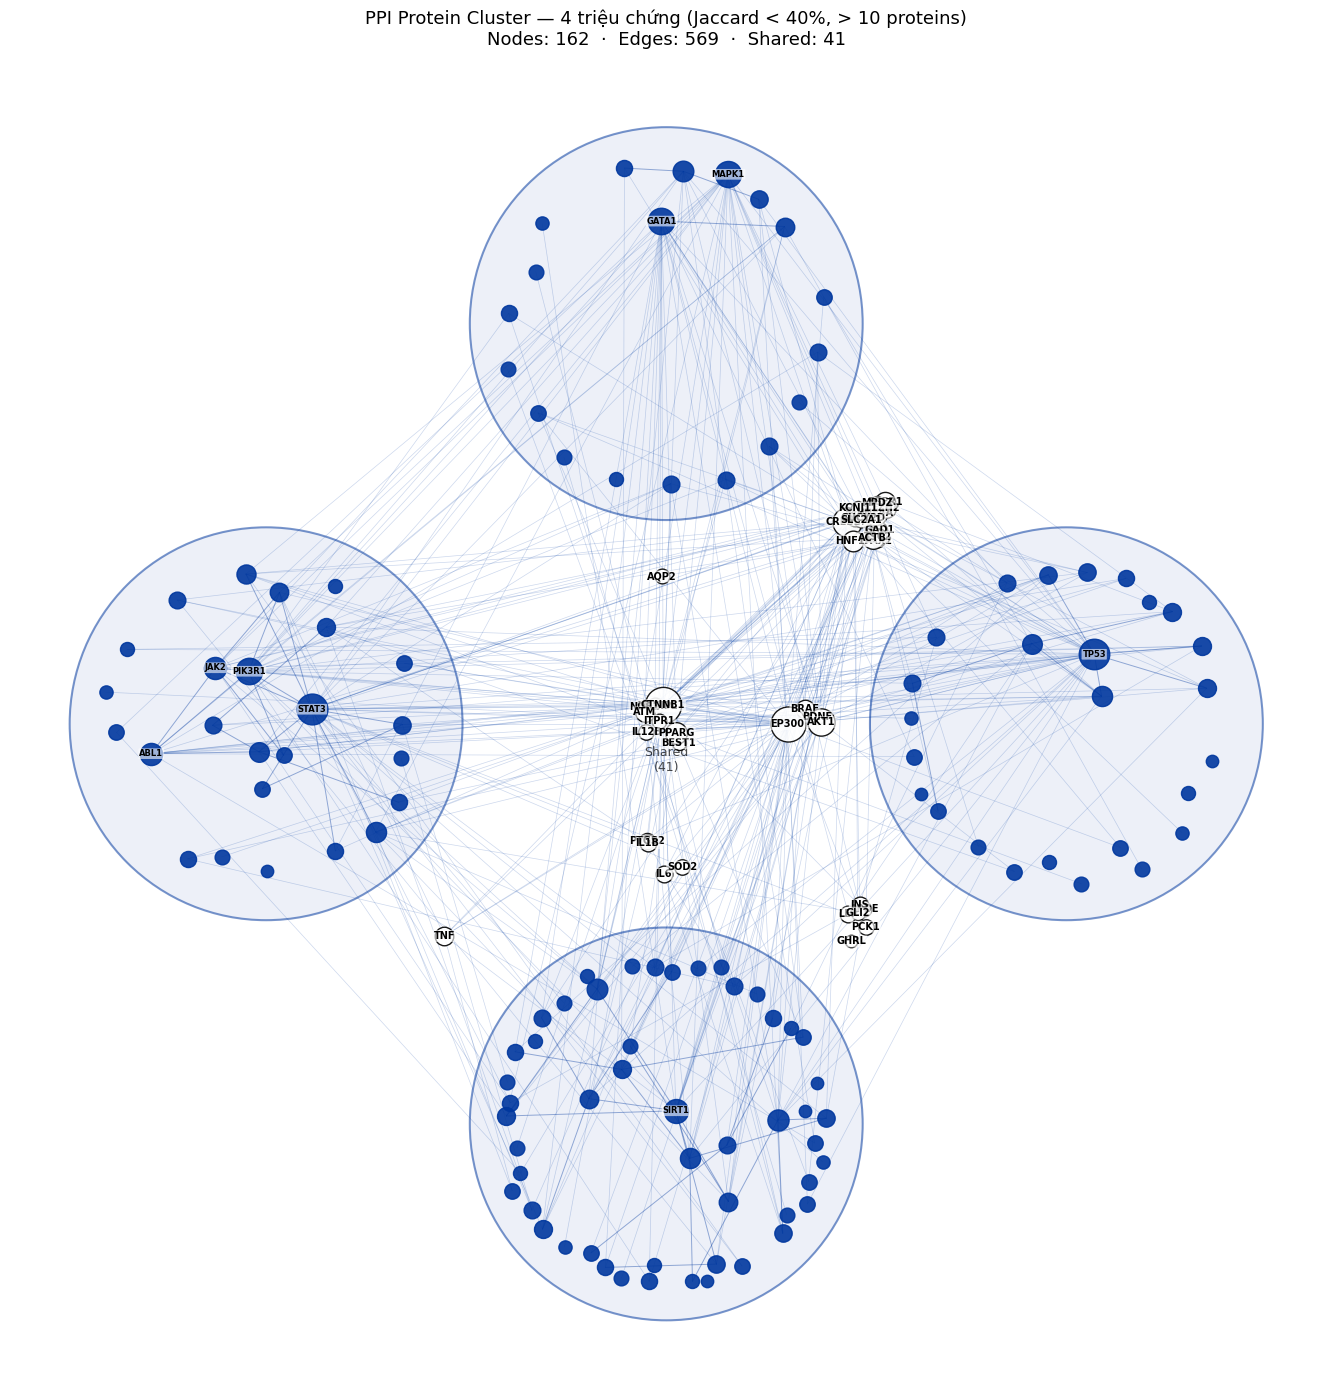

In [ ]:
"""
PPI Network — Vẽ cụm đơn giản, rõ ràng
Mỗi triệu chứng = 1 cụm riêng, node shared nối giữa các cụm
"""

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import defaultdict
from itertools import combinations

# ─── ĐƯỜNG DẪN FILE ───────────────────────────────────────────────────────────
BASE = r"D:\sciadv.adh0215_data_s1_to_s15\adh0215_Data_S1_to_S13"
PATH_HERB_TARGET  = rf"{BASE}\S4-1. HIT_herb_target_data_0412dropna.csv"
PATH_GENECARD     = r"D:\GeneCards-SearchResults.csv"
PATH_INTERACTOME  = rf"{BASE}\S2. interactome2019.txt"
PATH_SYMPTOM_GENE = rf"{BASE}\S1. TCM_symptom_genes_s20_0427.txt"

# ─── LOAD ─────────────────────────────────────────────────────────────────────
herb_target = pd.read_csv(PATH_HERB_TARGET)
target_gout = pd.read_csv(PATH_GENECARD)
target_gout = target_gout[target_gout["Relevance score"] > 0.2]

herb_target_gout = pd.merge(herb_target, target_gout, on="Gene Symbol", how="inner")
my_genes = set(str(i).strip() for i in herb_target_gout["entrez_id"].unique())

gi = pd.read_csv(PATH_INTERACTOME, sep='\t')
gi.columns = ["proteinA", "proteinB", "databases"]
gi["proteinA"] = gi["proteinA"].astype(str).str.strip()
gi["proteinB"] = gi["proteinB"].astype(str).str.strip()
gi_gout = gi[gi["proteinA"].isin(my_genes) & gi["proteinB"].isin(my_genes)]

unique_genes = pd.unique(pd.concat([gi_gout["proteinA"], gi_gout["proteinB"]]))
G = nx.Graph()
G.add_edges_from(zip(gi_gout["proteinA"], gi_gout["proteinB"]))
G_main    = G.subgraph(max(nx.connected_components(G), key=len)).copy()
ppi_nodes = set(G_main.nodes())

data = []
with open(PATH_SYMPTOM_GENE, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            data.append({'symptoms': parts[0], 'genes': parts[1:]})

df = pd.DataFrame(data)
df["gene_entrez"] = df["genes"].apply(
    lambda gl: [str(g).strip() for g in gl if str(g).strip() in unique_genes]
)
symp_df = df[["symptoms","gene_entrez"]].copy()
symp_df = symp_df.explode("gene_entrez").dropna(subset=["gene_entrez"])

symptom_proteins = {}
for cui, group in symp_df.groupby("symptoms"):
    overlap = set(group["gene_entrez"].tolist()) & ppi_nodes
    if len(overlap) > 10:
        symptom_proteins[cui] = overlap

# ─── CHỌN TRIỆU CHỨNG JACCARD < 0.4 ──────────────────────────────────────────
def jaccard(A, B):
    return len(A & B) / len(A | B) if A | B else 0.0

THRESHOLD = 0.40
TOP_N     = 4

candidates = sorted(symptom_proteins.items(), key=lambda x: len(x[1]), reverse=True)
selected   = []
for cui, prots in candidates:
    if all(jaccard(prots, symptom_proteins[s]) < THRESHOLD for s in selected):
        selected.append(cui)
    if len(selected) == TOP_N:
        break

top4_prots = {k: symptom_proteins[k] for k in selected}

# ─── ENTREZ → GENE SYMBOL ─────────────────────────────────────────────────────
herb_target_gout["entrez_id"] = herb_target_gout["entrez_id"].astype(str).str.strip()
entrez_to_sym = dict(zip(herb_target_gout["entrez_id"],
                         herb_target_gout["Gene Symbol"].astype(str)))

# ─── XÂY DỰNG GRAPH MỚI: NODE LÀ TRIỆU CHỨNG + PROTEIN ──────────────────────
# Dùng community-style layout:
# - Mỗi triệu chứng là 1 "super-node" ở trung tâm cụm
# - Protein unique nằm quanh cụm đó
# - Protein shared nằm giữa các cụm liên quan

node_membership = defaultdict(set)
for sid, prots in top4_prots.items():
    for p in prots:
        node_membership[p].add(sid)

all_protein_nodes = set()
for prots in top4_prots.values():
    all_protein_nodes.update(prots)

sub = G_main.subgraph(all_protein_nodes).copy()

# ─── THỦ CÔNG ĐẶT VỊ TRÍ: VÒNG TRÒN CHO TỪNG CỤM ────────────────────────────
N = len(selected)
CLUSTER_RADIUS   = 5.5   # khoảng cách tâm cụm tới gốc
INNER_RADIUS_UNI = 2.2   # bán kính vòng protein unique
INNER_RADIUS_SHR = 1.0   # bán kính vòng protein shared (gần tâm cụm)

# Tâm của từng cụm
cluster_centers = {}
for i, sid in enumerate(selected):
    angle = 2 * np.pi * i / N - np.pi/2       # bắt đầu từ đỉnh
    cx = CLUSTER_RADIUS * np.cos(angle)
    cy = CLUSTER_RADIUS * np.sin(angle)
    cluster_centers[sid] = (cx, cy)

# Đặt vị trí từng node protein
pos = {}

for sid, (cx, cy) in cluster_centers.items():
    unique_nodes = [n for n in top4_prots[sid]
                    if len(node_membership[n]) == 1]
    shared_nodes_local = [n for n in top4_prots[sid]
                          if len(node_membership[n]) > 1]

    # Unique: vòng đều quanh tâm cụm (dùng spring_layout local)
    if unique_nodes:
        sg = sub.subgraph(unique_nodes)
        if sg.number_of_edges() > 0:
            p = nx.spring_layout(sg, k=1.8, iterations=80,
                                 seed=hash(sid) % 999, weight=None)
            coords = np.array([p[n] for n in unique_nodes])
        else:
            angles2 = np.linspace(0, 2*np.pi, len(unique_nodes), endpoint=False)
            coords  = np.column_stack([np.cos(angles2), np.sin(angles2)])

        coords -= coords.mean(axis=0)
        r = np.abs(coords).max()
        if r > 0:
            coords = coords / r * INNER_RADIUS_UNI
        for i2, n in enumerate(unique_nodes):
            pos[n] = np.array([cx, cy]) + coords[i2]

    # Shared: nằm giữa các tâm cụm chứa nó
    for n in shared_nodes_local:
        if n not in pos:
            members = list(node_membership[n])
            cx_avg = np.mean([cluster_centers[s][0] for s in members])
            cy_avg = np.mean([cluster_centers[s][1] for s in members])
            # Jitter nhỏ để tránh chồng
            rng = np.random.default_rng(hash(n) % 9999)
            jitter = rng.uniform(-0.3, 0.3, size=2)
            pos[n] = np.array([cx_avg, cy_avg]) + jitter

# Fallback
for n in sub.nodes():
    if n not in pos:
        pos[n] = np.zeros(2)

degree  = dict(sub.degree())
max_deg = max(degree.values()) if degree else 1

# ─── VẼ ───────────────────────────────────────────────────────────────────────
GRAY_LEVELS = ["#00379EFF", "#00379EFF", "#00379EFF", "#00379EFF"]
CLUSTER_COLORS = {sid: GRAY_LEVELS[i % len(GRAY_LEVELS)]
                  for i, sid in enumerate(selected)}
SHARED_COLOR   = "white"

fig, ax = plt.subplots(figsize=(14, 14))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ── Vòng tròn cụm (nền xám nhạt) ──
for sid, (cx, cy) in cluster_centers.items():
    circle = plt.Circle((cx, cy), INNER_RADIUS_UNI + 0.5,
                         color=CLUSTER_COLORS[sid],
                         fill=True, alpha=0.07, zorder=0)
    ax.add_patch(circle)
    circle2 = plt.Circle((cx, cy), INNER_RADIUS_UNI + 0.5,
                          color=CLUSTER_COLORS[sid],
                          fill=False, linewidth=1.5, alpha=0.5,
                          linestyle="-", zorder=0)
    ax.add_patch(circle2)

# ── Edges bên trong cụm ──
for u, v in sub.edges():
    mu, mv = node_membership[u], node_membership[v]
    same_cluster = (len(mu) == 1 and mu == mv)
    if same_cluster:
        col, lw, al = CLUSTER_COLORS[list(mu)[0]], 0.7, 0.4
    else:
        col, lw, al = "#003DA5", 0.5, 0.2      # edge liên cụm / shared
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    ax.plot([x0, x1], [y0, y1], color=col, lw=lw, alpha=al, zorder=1)

# ── Nodes ──
for n in sub.nodes():
    x, y      = pos[n]
    is_shared = len(node_membership[n]) > 1
    color     = SHARED_COLOR if is_shared else CLUSTER_COLORS[list(node_membership[n])[0]]
    edge_col  = "black" if is_shared else CLUSTER_COLORS[list(node_membership[n])[0]]
    size      = 80 + 600 * (degree[n] / max_deg)
    ax.scatter(x, y, s=size, c=color, zorder=3,
               edgecolors=edge_col, linewidths=1.0, alpha=0.9)

# ── Labels protein (chỉ hub + shared) ──
deg_thresh = sorted(degree.values(), reverse=True)[min(12, len(degree)-1)]
for n in sub.nodes():
    if degree[n] >= deg_thresh or len(node_membership[n]) > 1:
        x, y = pos[n]
        lbl  = entrez_to_sym.get(str(n), str(n))
        fs   = 7 if len(node_membership[n]) > 1 else 6
        ax.text(x, y, lbl, fontsize=fs, color="black", fontweight="bold",
                ha="center", va="center", zorder=5,
                bbox=dict(boxstyle="round,pad=0.1", fc="white",
                          ec="none", alpha=0.6))

# ── Nhãn tên cụm (symptom ID) ──
for i, sid in enumerate(selected):
    cx, cy = cluster_centers[sid]
    # Đặt nhãn bên ngoài vòng tròn
    angle  = 2 * np.pi * i / N - np.pi/2
    lx     = (CLUSTER_RADIUS + INNER_RADIUS_UNI + 1.2) * np.cos(angle)
    ly     = (CLUSTER_RADIUS + INNER_RADIUS_UNI + 1.2) * np.sin(angle)
    unique_n = sum(1 for n in top4_prots[sid]
                   if len(node_membership[n]) == 1)
    shared_n = sum(1 for n in top4_prots[sid]
                   if len(node_membership[n]) > 1)
    

# ── Ghi chú shared ──
shared_all = [n for n in sub.nodes() if len(node_membership[n]) > 1]
ax.text(0, -0.5, f"Shared\n({len(shared_all)})",
        fontsize=9, color="black", ha="center", va="center", alpha=0.7)

# ── Tiêu đề ──
ax.set_title(
    f"PPI Protein Cluster — {TOP_N} triệu chứng (Jaccard < {THRESHOLD:.0%}, > 10 proteins)\n"
    f"Nodes: {sub.number_of_nodes()}  ·  Edges: {sub.number_of_edges()}  ·  Shared: {len(shared_all)}",
    fontsize=13, pad=16, color="black")

ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()

out = "ppi_cluster_simple.png"
plt.savefig(out, dpi=180, bbox_inches="tight", facecolor="white")
print(f"✅ Đã lưu: {out}")
plt.show()